# Monte Carlo Option Pricing

Prices vanilla and exotic options by simulation: bump-and-revalue
Greeks, path-dependent payoffs, correlated baskets, a dynamic
delta-hedging P&L study, and least squares Monte Carlo for early
exercise.

| Section | Topic | Methods |
|---|---|---|
| 2.1 | Single-asset pricing | GBM paths; call value with delta, rho, and vega by bump and revalue; average-strike Asian call; double-barrier knockout put |
| 2.2 | Multi-asset pricing | Correlated GBM for two stocks, single-name calls, basket option, correlation sensitivity, monthly-rebalanced basket |
| 2.3 | Dynamic delta hedging | Real-world paths hedged at implied volatility, weekly vs daily rebalancing, hedge cost against the Black-Scholes premium |
| 2.4 | Early exercise | Least squares Monte Carlo for an American put with a quadratic regression basis |
| 2.5 | Term-structure inputs | Time-varying forward rates and volatility with discrete dividends, price-return vs total-return calls |

All inputs are set inline and the notebook runs top to bottom with no
external data.

**Imports:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from scipy.optimize import brentq
import math
import QuantLib as ql

### 2.1 Monte-Carlo Valuation (Single-Asset)
- $S = 100  \quad$
- $K = 100  \quad$
- $r_f = 3\% = 0.03  \quad$
- $T = 1 \text{ year}  \quad$
- $\sigma = 20\% = 0.20  \quad$
- $q = 0 \quad \text{(no dividends)}  \quad$
- $N = 12 \quad \text{(monthly time steps)}  \quad$
- $\Delta t = \frac{1}{12}  \quad$

#### a) Call Option Value

Option Value (S_0 = 100): 9.1760
MC Error (S_0 = 100):     0.1404


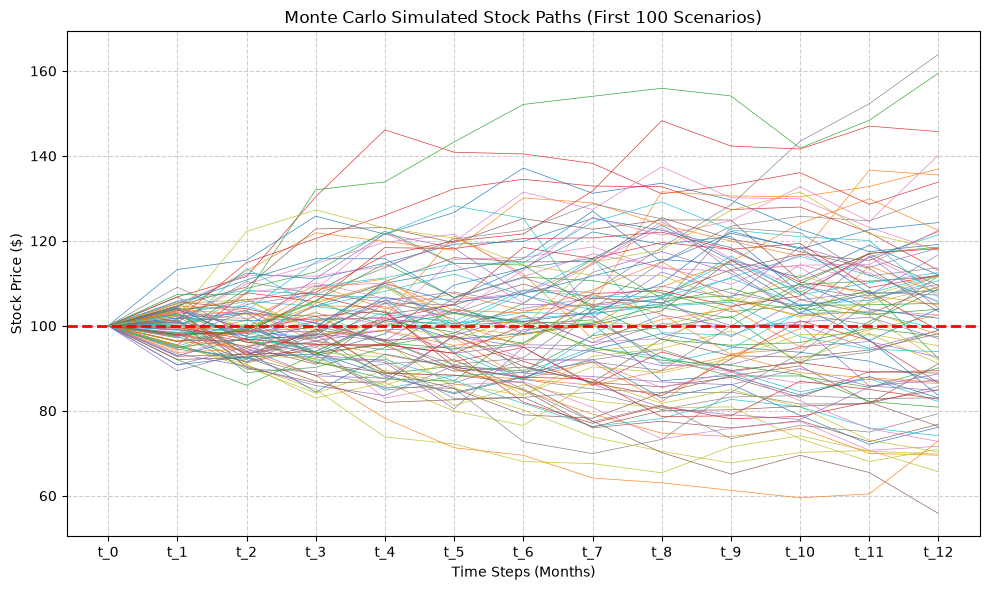

In [2]:
S0 = 100
K = 100
r = 0.03
sigma = 0.20
T = 1.0
M_steps = 12
N_paths = 10000


def GBM_paths_sim(S0, r, sigma, T, steps, N_paths):
    rng = np.random.default_rng(42)
    dt = T / steps
    S_paths = np.zeros((N_paths, steps+1))
    S_paths[:, 0] = S0

    for t in range(steps):
        Zt = rng.standard_normal(size=N_paths)
        drift = (r - 0.5 * sigma**2) * dt
        diffusion = sigma * np.sqrt(dt) * Zt
        S_paths[:, t+1] = S_paths[:, t] * np.exp(drift + diffusion)

    col = [f"t_{i}" for i in range(steps + 1)]
    df = pd.DataFrame(S_paths, columns=col)
    return df

def get_call_value(df_paths, K, r, T):
    S_T = df_paths.iloc[:, -1]

    payoffs = np.maximum(S_T - K, 0)
    disc_payoffs = np.exp(-r * T) * payoffs
    df_val = pd.DataFrame(disc_payoffs)

    option_val = disc_payoffs.mean()
    mc_err = disc_payoffs.std(ddof=1) / np.sqrt(len(disc_payoffs))

    return option_val, mc_err, df_val

df_sim_S_paths = GBM_paths_sim(S0, r, sigma, T, M_steps, N_paths)
call_val, mc_err, df_val= get_call_value(df_sim_S_paths, K, r, T)


print(f"Option Value (S_0 = 100): {call_val:.4f}")
print(f"MC Error (S_0 = 100):     {mc_err:.4f}")

plt.rcdefaults()
plt.figure(figsize=(10, 6))
plt.plot(df_sim_S_paths.iloc[:100, :].T, lw=0.5, alpha=0.9)
plt.axhline(y=100.0, color='red', linestyle='--', linewidth=2, label='Strike Price (K=100)')
plt.title("Monte Carlo Simulated Stock Paths (First 100 Scenarios)")
plt.xlabel("Time Steps (Months)")
plt.ylabel("Stock Price ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


#### Option delta with a 10% shift in the stock (S = 110)?
$$
\Delta \approx \frac{C(S_0^{\text{up}}) - C(S_0)}{S_0^{\text{up}} - S_0}
$$

In [3]:
S0_up =  110

df_S_up_sim_paths = GBM_paths_sim(S0_up, r, sigma, T, M_steps, N_paths)
call_val_up, mc_err_up, df_val_up = get_call_value(df_S_up_sim_paths, K, r, T)
delta = (call_val_up - call_val) / (S0_up - S0)

print(f"Option Value (S_0 = 110): {call_val_up:.4f}")
print(f"MC Error (S_0 = 110):     {mc_err_up:.4f}")
print(f"Option Delta:         {delta:.4f}")

Option Value (S_0 = 110): 15.9732
MC Error (S_0 = 110):     0.1831
Option Delta:         0.6797


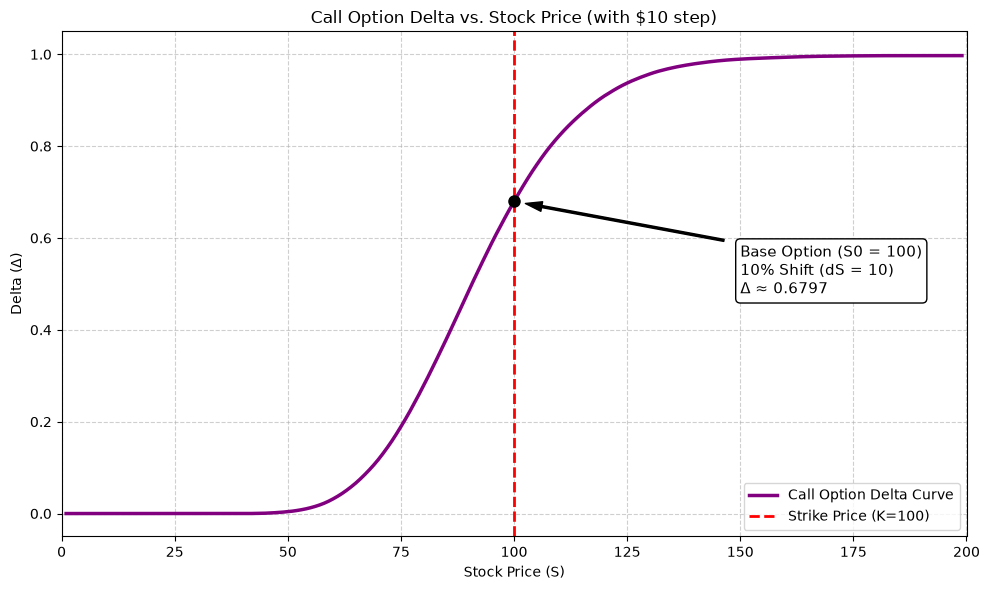

In [4]:
stock_prices = np.arange(1, 200, 1)
deltas = []
dS = 10

for S in stock_prices:
    df_base = GBM_paths_sim(S, r, sigma, T, M_steps, N_paths)
    val_base, mc_err_base, _ = get_call_value(df_base, K, r, T)

    df_shifted = GBM_paths_sim(S + dS, r, sigma, T, M_steps, N_paths)
    val_shifted, mc_err_shift, _ = get_call_value(df_shifted, K, r, T)

    delta = (val_shifted - val_base) / dS
    deltas.append(delta)

index_100 = 100 - 1
delta_100 = deltas[index_100]



plt.rcdefaults()
plt.close('all')

plt.figure(figsize=(10, 6))

plt.plot(stock_prices, deltas, color='purple', linewidth=2.5, label='Call Option Delta Curve')
plt.axvline(x=K, color='red', linestyle='--', linewidth=2, label='Strike Price (K=100)')
plt.plot(100, delta_100, marker='o', markersize=8, color='black')

plt.annotate(
    f'Base Option (S0 = 100)\n10% Shift (dS = 10)\nΔ ≈ {delta_100:.4f}',
    xy=(100, delta_100),
    xytext=(150, delta_100 - 0.20),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

plt.title("Call Option Delta vs. Stock Price (with $10 step)")
plt.xlabel("Stock Price (S)")
plt.ylabel("Delta (Δ)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right")

plt.ylim(-0.05, 1.05)
plt.xlim(0, 200)

plt.tight_layout()
plt.show()


#### Option rho with a 10% shift in the risk-free rate (r = 3.3%)?
$$
\rho \approx \frac{C(r^{\text{up}}) - C(r)}{r^{\text{up}} - r}
$$

In [5]:
r_up = 0.033
df_r_up_sim_paths = GBM_paths_sim(S0, r_up, sigma, T, M_steps, N_paths)
call_val_r_up, mc_err_r_up, df_val_r_up = get_call_value(df_r_up_sim_paths, K, r_up, T)
rho = (call_val_r_up - call_val) / (r_up - r)

print(f"Option Value (r = 3.3%): {call_val_r_up:.4f}")
print(f"MC Error (r = 3.3%):     {mc_err_r_up:.4f}")
print(f"Option Rho:              {rho:.4f}")

Option Value (r = 3.3%): 9.3264
MC Error (r = 3.3%):     0.1413
Option Rho:              50.1441


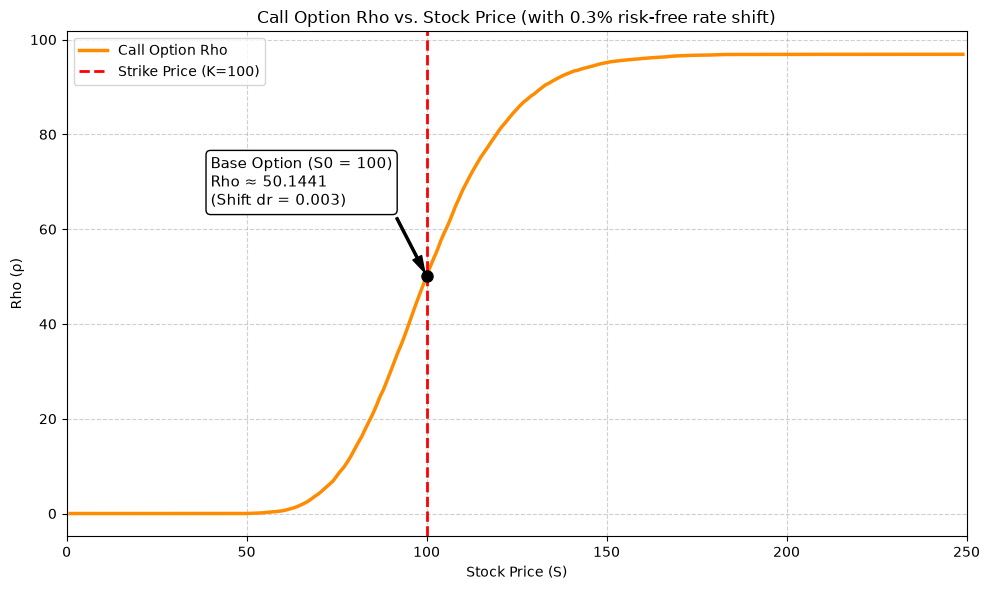

In [6]:
stock_prices = list(range(1, 250, 1))
rhos = []
dr = 0.003
r_up = 0.033


for S in stock_prices:
    df_base = GBM_paths_sim(S, r, sigma, T, M_steps, N_paths)
    val_base, _, _ = get_call_value(df_base, K, r, T)

    df_rho_up = GBM_paths_sim(S, r_up, sigma, T, M_steps, N_paths)
    val_rho_up, _, _ = get_call_value(df_rho_up, K, r_up, T)

    rho = (val_rho_up - val_base) / dr
    rhos.append(rho)

plt.rcdefaults()
plt.close('all')

plt.figure(figsize=(10, 6))
plt.plot(stock_prices, rhos, color='darkorange', linewidth=2.5, label='Call Option Rho')
plt.axvline(x=K, color='red', linestyle='--', linewidth=2, label='Strike Price (K=100)')
index_100 = 100 - 1
rho_100 = rhos[index_100]
plt.plot(100, rho_100, marker='o', markersize=8, color='black')
plt.annotate(
    f'Base Option (S0 = 100)\n'
    f'Rho ≈ {rho_100:.4f}\n'
    f'(Shift dr = {dr})', # Showing the absolute shift used
    xy=(100, rho_100),
    xytext=(40, rho_100 + 15), # Adjusted text placement to fit extra line
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

plt.title("Call Option Rho vs. Stock Price (with 0.3% risk-free rate shift)")
plt.xlabel("Stock Price (S)")
plt.ylabel("Rho (ρ)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper left")

plt.xlim(0, 250)
plt.tight_layout()
plt.show()

#### Option Vega with a 10% shift in the volatility ($\sigma = 22\%$):
$$
\nu \approx \frac{C(\sigma^{\text{up}}) - C(\sigma)}{\sigma^{\text{up}} - \sigma}
$$

In [7]:
sigma_up = 0.22
df_sigma_up_sim_paths = GBM_paths_sim(S0, r, sigma_up, T, M_steps, N_paths)
call_val_sigma_up, mc_err_sigma_up, df_val_sigma_up = get_call_value(df_sigma_up_sim_paths, K, r, T)
vega = (call_val_sigma_up - call_val) / (sigma_up - sigma)
print(f"Option Value (sigma = 22%): {call_val_sigma_up:.4f}")
print(f"MC Error (sigma = 22%):     {mc_err_sigma_up:.4f}")
print(f"Option Vega:                {vega:.4f}")

Option Value (sigma = 22%): 9.9266
MC Error (sigma = 22%):     0.1552
Option Vega:                37.5306


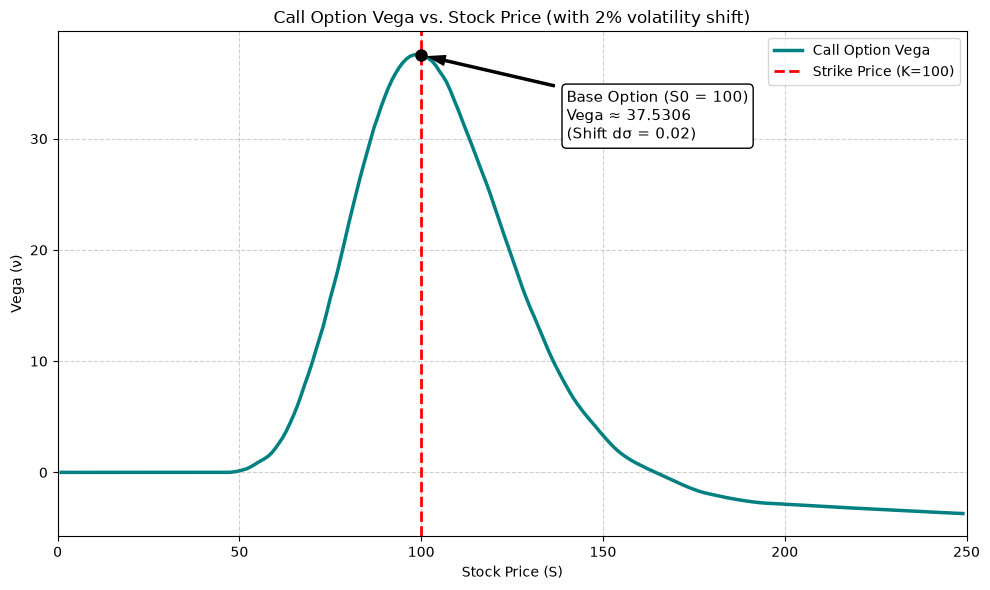

In [8]:
stock_prices = list(range(1, 250, 1))
vegas = []
sigma_up = 0.22
d_sigma = 0.02

for S in stock_prices:
    df_base = GBM_paths_sim(S, r, sigma, T, M_steps, N_paths)
    val_base, _, _ = get_call_value(df_base, K, r, T)

    df_sigma_up = GBM_paths_sim(S, r, sigma_up, T, M_steps, N_paths)
    val_sigma_up, _, _ = get_call_value(df_sigma_up, K, r, T)

    vega = (val_sigma_up - val_base) / d_sigma
    vegas.append(vega)

plt.rcdefaults()
plt.close('all')
plt.figure(figsize=(10, 6))

plt.plot(stock_prices, vegas, color='teal', linewidth=2.5, label='Call Option Vega')
plt.axvline(x=K, color='red', linestyle='--', linewidth=2, label='Strike Price (K=100)')

index_100 = 100 - 1
vega_100 = vegas[index_100]
plt.plot(100, vega_100, marker='o', markersize=8, color='black')
plt.annotate(
    f'Base Option (S0 = 100)\n'
    f'Vega ≈ {vega_100:.4f}\n'
    f'(Shift dσ = {d_sigma})',
    xy=(100, vega_100),
    xytext=(140, vega_100 * 0.8),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

plt.title("Call Option Vega vs. Stock Price (with 2% volatility shift)")
plt.xlabel("Stock Price (S)")
plt.ylabel("Vega (ν)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper right")

plt.xlim(0, 250)
plt.tight_layout()
plt.show()

#### b) Value a call option where the strike price at maturity is the average of stock prices from months 1 to 12?

**Asian Call with Arithmetic-average strike**
$$
\text{Payoff}_{\text{arith}} = \max\left(S_{12} - \frac{1}{12}\sum_{m=1}^{12} S_m,\, 0\right)
$$

- With Monte Carlo estimator with \(N\) simulated paths is
$$
\hat C_0^{\text{arith}} = e^{-rT}\,\frac{1}{N}\sum_{i=1}^{N}
\max\left(S_{12}^{(i)} - \frac{1}{12}\sum_{m=1}^{12} S_m^{(i)},\, 0\right)
$$

**Asian Call with Geometric-average strike**
$$
\text{Payoff}_{\text{geom}} = \max\left(S_{12} - \left(\prod_{m=1}^{12} S_m\right)^{1/12},\, 0\right)
$$

- With Monte Carlo estimator with \(N\) simulated paths is
$$
\hat C_0^{\text{geom}} = e^{-rT}\,\frac{1}{N}\sum_{i=1}^{N}
\max\left(S_{12}^{(i)} - \left(\prod_{m=1}^{12} S_m^{(i)}\right)^{1/12},\, 0\right)
$$



In [9]:
df_asian_paths = GBM_paths_sim(S0, r, sigma, T, M_steps, N_paths)
path_prices_1to12M = df_asian_paths.iloc[:, 1:]


arithmetic_averages = path_prices_1to12M.mean(axis=1)
arith_payoffs = np.maximum(arithmetic_averages - K, 0)
arith_val = np.exp(-r * T) * arith_payoffs.mean()
MC_arith_err = (np.exp(-r * T) * arith_payoffs).std(ddof=1) / np.sqrt(N_paths)


geometric_averages = np.exp(np.log(path_prices_1to12M).mean(axis=1))
geo_payoffs = np.maximum(geometric_averages - K, 0)
geo_val = np.exp(-r * T) * geo_payoffs.mean()
MC_geo_err = (np.exp(-r * T) * geo_payoffs).std(ddof=1) / np.sqrt(N_paths)

print(f"Arithmetic Asian Value: {arith_val:.4f} (MC Error: {MC_arith_err:.4f})")
print(f"Geometric Asian Value:  {geo_val:.4f} (MC Error: {MC_geo_err:.4f})")

Arithmetic Asian Value: 5.5153 (MC Error: 0.0816)
Geometric Asian Value:  5.3231 (MC Error: 0.0791)


#### c) Value a put option which is knocked out if S>130 or S<80?
Value a knock-out put option that becomes worthless if the stock price ever crosses the barrier region during the monitoring period.


- **Knock-out condition (barrier)**: the option is knocked out if at any monitored month,
$$\quad S_t > 130 \quad \text{or} \quad S_t < 80
\qquad \text{for some } t \in \{1,\dots,12\}
$$

- **Put pathwise payoff at maturity (with knock-out)**
$$
\text{Payoff}
=
\mathbf{1}_{\{80 \le S_t \le 130,\ \forall t=1,\dots,12\}}
\cdot
\max(K - S_{12}, 0)
$$

- **Monte Carlo estimator (with \(N\) simulated paths)**
    -  $S_t^{(n)}$ denote the stock price at month \(t\) on simulated path \(n\)

$$
\hat V_0
=
e^{-rT}\,\frac{1}{N}\sum_{i=1}^{N}
\left(
\mathbf{1}_{\{80 \le S_t^{(n)} \le 130,\ \forall m=1,\dots,12\}}
\cdot
\max(K - S_{12}^{(n)}, 0)
\right)
$$

Barrier Option Value: 2.4534
MC Error:              0.0467
Paths Survived:        6630 out of 10000


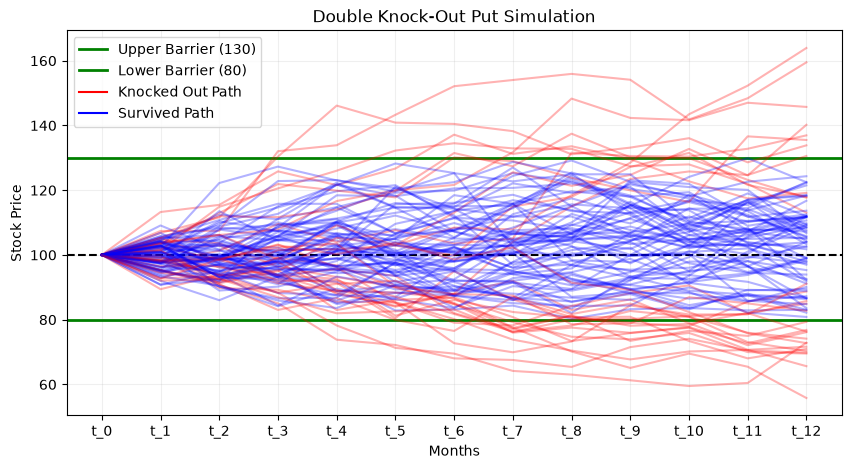

In [10]:
L = 80
U = 130
K = 100

df_barrier_paths = GBM_paths_sim(S0, r, sigma, T, M_steps, N_paths)

hit_upper = (df_barrier_paths > U).any(axis=1)
hit_lower = (df_barrier_paths < L).any(axis=1)

knocked_out = hit_upper | hit_lower
S_T = df_barrier_paths.iloc[:, -1]
put_payoffs = np.maximum(K - S_T, 0)

barrier_payoffs = put_payoffs.copy()
barrier_payoffs[knocked_out] = 0

disc_barrier_payoffs = np.exp(-r * T) * barrier_payoffs
barrier_val = disc_barrier_payoffs.mean()
barrier_err = disc_barrier_payoffs.std(ddof=1) / np.sqrt(N_paths)

print(f"Barrier Option Value: {barrier_val:.4f}")
print(f"MC Error:              {barrier_err:.4f}")

survived_count = (~knocked_out).sum()
print(f"Paths Survived:        {survived_count} out of {N_paths}")

plt.figure(figsize=(10, 5))

plt.axhline(U, color='green', lw=2, label=f"Upper Barrier ({U})")
plt.axhline(L, color='green', lw=2, label=f"Lower Barrier ({L})")
plt.axhline(K, color='black', ls='--')

for i in range(100):
    plt.plot(df_barrier_paths.iloc[i], color='red' if knocked_out[i] else 'blue', alpha=0.3)

plt.plot([], [], color='red', label='Knocked Out Path')
plt.plot([], [], color='blue', label='Survived Path')

plt.title("Double Knock-Out Put Simulation")
plt.xlabel("Months")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### 2.2 Monte-Carlo Valuation (Multi-Asset)
- $
S_1(0) = S_2(0) = 50
$
- $T = 1 \text{ year}$
- $
r_f = 3\%
$
- $
\sigma_1 = 20\%  \quad \sigma_2 = 30\%
$
- $
\rho_{12} = 0.25 \quad \text{(correlation between } S_1 \text{ and } S_2\text{)}
$

#### a) Value of a call option on the individual stocks with K = 50?
**Monte Carlo $N_{\text{paths}}$ simulated scenarios:**

$
\hat C_{1,0}=e^{-rT}\frac{1}{N_{\text{paths}}}\sum_{i=1}^{N_{\text{paths}}}\max(S_{1,T}^{(i)}-50,0) \quad
$
and$\quad
\hat C_{2,0}=e^{-rT}\frac{1}{N_{\text{paths}}}\sum_{i=1}^{N_{\text{paths}}}\max(S_{2,T}^{(i)}-50,0)
$

In [11]:
S1 = 50
S2 = 50
K = 50
r = 0.03
T = 1.0
sigma1 = 0.2
sigma2 = 0.3
steps = 12
N_paths = 10000
corr_S12 = 0.25

df_S1 = GBM_paths_sim(S1, r, sigma1, T, steps, N_paths)
val_S1, err_S1, _ = get_call_value(df_S1, K, r, T)

df_S2 = GBM_paths_sim(S2, r, sigma2, T, steps, N_paths)
val_S2, err_S2, _ = get_call_value(df_S2, K, r, T)

print(f"Call on S1 (Sigma = 20%): Value = {val_S1:.4f} | MC Error = {err_S1:.4f}")
print(f"Call on S2 (Sigma = 30%): Value = {val_S2:.4f} | MC Error = {err_S2:.4f}")

Call on S1 (Sigma = 20%): Value = 4.5880 | MC Error = 0.0702
Call on S2 (Sigma = 30%): Value = 6.4659 | MC Error = 0.1090


#### b) Value a basket option (Sum of S1 and S2) with one share of each stock and a strike of 100?
$B_T = S_{1,T} + S_{2,T}$

- **Monte Carlo estimator:**
$\quad
\hat C_{B,0}=e^{-rT}\frac{1}{N_{\text{paths}}}
\sum_{i=1}^{N_{\text{paths}}}
\max\!\left(S_{1,T}^{(i)}+S_{2,T}^{(i)}-100,0\right)
$

- **Correlation matrix (for simulation shocks):**
$
\Sigma_Z =
\begin{bmatrix}
1 & \rho \\
\rho & 1
\end{bmatrix}
\quad\text{with}\quad \rho = 0.25 \Rightarrow \text{Cholesky factorization} \quad \Sigma_Z = LL^\top
$

- **Correlated normal shocks (per time step):**
$ \quad
\mathbf{Z}_t =
\begin{bmatrix}
Z_{1,t} \\
Z_{2,t}
\end{bmatrix}
= L
\begin{bmatrix}
U_{1,t} \\
U_{2,t}
\end{bmatrix},
\qquad
U_{1,t},U_{2,t}\sim N(0,1)\ \text{i.i.d.}
$
    - **Bivariate case:**
      $\quad Z_{1,t} = U_{1,t}\quad$ and $\quad Z_{2,t} = \rho\,U_{1,t} + \sqrt{1-\rho^2}\,U_{2,t}$


- **Monthly GBM for S1 and S2:**
$$
S_{1,t+\Delta t}
=
S_{1,t}\exp\!\left[\left(r-\frac12\sigma_1^2\right)\Delta t+\sigma_1\sqrt{\Delta t}\,Z_{1,t}\right]
$$

$$
S_{2,t+\Delta t}
=
S_{2,t}\exp\!\left[\left(r-\frac12\sigma_2^2\right)\Delta t+\sigma_2\sqrt{\Delta t}\,Z_{2,t}\right]
$$

In [12]:
K = 100

def bivariate_GBM_sim(S1,S2, r, sigma1, sigma2,corr_S12,  T, steps, N_paths):
    rng = np.random.default_rng(42)

    dt = T / steps
    S1_paths = np.zeros((N_paths, steps+1))
    S2_paths = np.zeros((N_paths, steps+1))
    S1_paths[:, 0] = S1
    S2_paths[:, 0] = S2

    for t in range(steps):
        U1 = rng.standard_normal(size=N_paths)
        U2 = rng.standard_normal(size=N_paths)
        Z1 = U1
        Z2 = corr_S12 * U1 + np.sqrt(1 - corr_S12**2) * U2

        drift1 = (r - 0.5 * sigma1**2) * dt
        diff1 = sigma1 * np.sqrt(dt) * Z1

        drift2 = (r - 0.5 * sigma2**2) * dt
        diff2 = sigma2 * np.sqrt(dt) * Z2

        # Update prices for the next step (t+1)
        S1_paths[:, t+1] = S1_paths[:, t] * np.exp(drift1 + diff1)
        S2_paths[:, t+1] = S2_paths[:, t] * np.exp(drift2 + diff2)
    cols = [f"t_{i}" for i in range(steps + 1)]
    df_S1 = pd.DataFrame(S1_paths, columns=cols)
    df_S2 = pd.DataFrame(S2_paths, columns=cols)
    return df_S1, df_S2


df_S1, df_S2 = bivariate_GBM_sim(S1, S2, r, sigma1, sigma2, corr_S12, T, steps, N_paths)
df_basket = df_S1 + df_S2

basket_val, basket_err, _ = get_call_value(df_basket, K, r, T)

print(f"Basket Call Option: Value [Corr(S1,S2) = 0.25] = {basket_val:.4f} | MC Error = {basket_err:.4f}\n")


Basket Call Option: Value [Corr(S1,S2) = 0.25] = 9.2961 | MC Error = 0.1425



#### c) Value of the basket if you change the correlation to 0% and 50%?

In [13]:
K = 100

df_S1_zero_corr, df_S2_zero_corr = bivariate_GBM_sim(S1, S2, r, sigma1, sigma2, 0.0, T, steps, N_paths)
df_basket_zero_corr = df_S1_zero_corr + df_S2_zero_corr

basket_val_zero_corr, basket_err_zero_corr, _ = get_call_value(df_basket_zero_corr, K, r, T)
print(f"Basket Call Option [Corr = 0.0]: Value = {basket_val_zero_corr:.4f} | MC Error = {basket_err_zero_corr:.4f}")

df_S1_50_corr, df_S2_50_corr = bivariate_GBM_sim(S1, S2, r, sigma1, sigma2, 0.5, T, steps, N_paths)
df_basket_50_corr = df_S1_50_corr + df_S2_50_corr


basket_val_50_corr, basket_err_50_corr, _ = get_call_value(df_basket_50_corr, K, r, T)

print(f"Basket Call Option [Corr = 0.5]: Value = {basket_val_50_corr:.4f} | MC Error = {basket_err_50_corr:.4f}")

Basket Call Option [Corr = 0.0]: Value = 8.5907 | MC Error = 0.1284
Basket Call Option [Corr = 0.5]: Value = 9.9569 | MC Error = 0.1561


--- Path Outcomes (Total 10,000 Paths per Scenario) ---
Correlation 0.0 : 5242 In-The-Money | 4758 Out-Of-The-Money
Correlation 0.25: 5150 In-The-Money | 4850 Out-Of-The-Money
Correlation 0.50: 5045 In-The-Money | 4955 Out-Of-The-Money



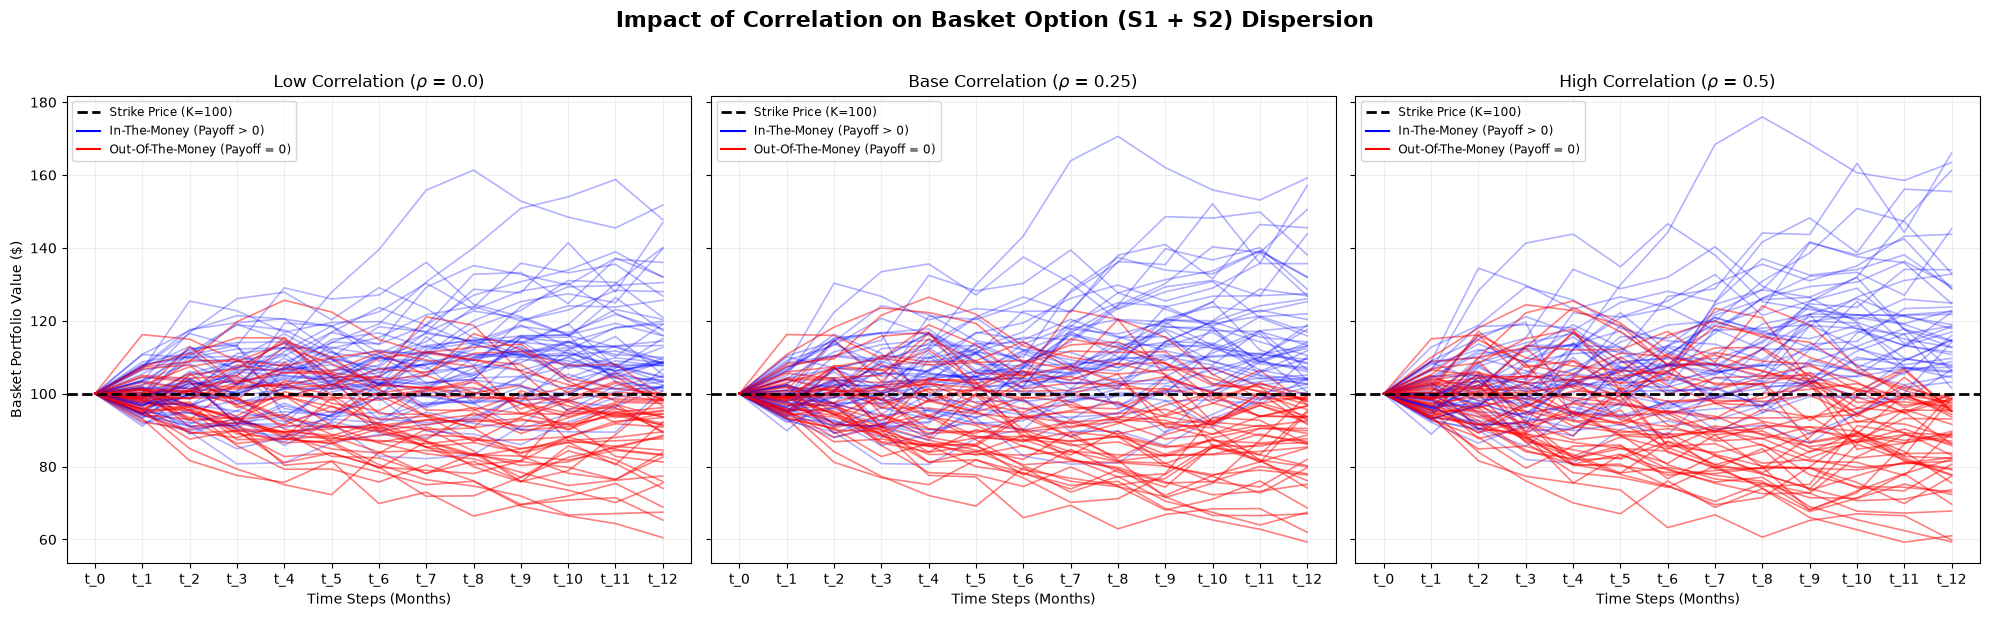

In [14]:
print("--- Path Outcomes (Total 10,000 Paths per Scenario) ---")
itm_0 = (df_basket_zero_corr.iloc[:, -1] > K).sum()
otm_0 = N_paths - itm_0
print(f"Correlation 0.0 : {itm_0} In-The-Money | {otm_0} Out-Of-The-Money")

itm_25 = (df_basket.iloc[:, -1] > K).sum()
otm_25 = N_paths - itm_25
print(f"Correlation 0.25: {itm_25} In-The-Money | {otm_25} Out-Of-The-Money")

itm_50 = (df_basket_50_corr.iloc[:, -1] > K).sum()
otm_50 = N_paths - itm_50
print(f"Correlation 0.50: {itm_50} In-The-Money | {otm_50} Out-Of-The-Money\n")



num_paths_to_plot = 100
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

scenarios = [
    {"title": "Low Correlation ($\\rho$ = 0.0)", "df": df_basket_zero_corr},
    {"title": "Base Correlation ($\\rho$ = 0.25)", "df": df_basket},
    {"title": "High Correlation ($\\rho$ = 0.5)", "df": df_basket_50_corr}
]

for col, scenario in enumerate(scenarios):
    ax = axes[col]
    df_to_plot = scenario["df"]
    for i in range(num_paths_to_plot):
        path = df_to_plot.iloc[i]
        if path.iloc[-1] > K:
            ax.plot(path, color='blue', alpha=0.3, linewidth=1.2)
        else:
            ax.plot(path, color='red', alpha=0.5, linewidth=1.2)

    ax.axhline(y=K, color='black', linestyle='--', linewidth=2, label=f'Strike Price (K={K})')
    ax.set_title(scenario["title"], fontsize=12)
    ax.set_xlabel("Time Steps (Months)", fontsize=10)
    if col == 0:
        ax.set_ylabel("Basket Portfolio Value ($)", fontsize=10)

    ax.grid(True, alpha=0.2)


    ax.plot([], [], color='blue', label='In-The-Money (Payoff > 0)')
    ax.plot([], [], color='red', label='Out-Of-The-Money (Payoff = 0)')
    ax.legend(loc='upper left', fontsize='small')
fig.suptitle("Impact of Correlation on Basket Option (S1 + S2) Dispersion", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### d) Value the basket option if the portfolio is rebalanced each month to the original 50%/50% weights of S1 and S2?

Let the portfolio value be $V_t$ with initial value $\quad V_0 = 100 $

At each monthly rebalancing date, reset portfolio weights to $\quad w_1 = 0.5,\quad w_2 = 0.5 $

The monthly portfolio update: $ \quad V_{t+1} = V_t\left[ 0.5\frac{S_{1,t+1}}{S_{1,t}} + 0.5\frac{S_{2,t+1}}{S_{2,t}} \right] $

The Monte Carlo estimator: $ \quad \hat V_0 = e^{-rT}\frac{1}{N}\sum_{i=1}^{N}\max(V_T^{(i)}-100,0) $

In [15]:
K = 100

V_paths = np.zeros((N_paths, steps + 1))
V_paths[:, 0] = 100
df_S1, df_S2 = bivariate_GBM_sim(S1, S2, r, sigma1, sigma2, corr_S12, T, steps, N_paths)

for t in range(steps):
    growth_S1 = df_S1.iloc[:, t+1] / df_S1.iloc[:, t]
    growth_S2 = df_S2.iloc[:, t+1] / df_S2.iloc[:, t]
    port_growth = (0.5 * growth_S1) + (0.5 * growth_S2)

    V_paths[:, t+1] = V_paths[:, t] * port_growth

df_rebalanced = pd.DataFrame(V_paths, columns=df_S1.columns)
rebal_val, rebal_err, _ = get_call_value(df_rebalanced, 100, r, T)

print(f"Rebalanced Basket: Call value = {rebal_val:.4f} with MC Error = {rebal_err:.4f}")

Rebalanced Basket: Call value = 9.2921 with MC Error = 0.1411


### 2.3 Dynamic Delta Hedging
- $S_0 = 100$
- $\mu_{RW} = 0.08$
- $\sigma_{RW} = 0.15$
- $K = 100$
- $r_f = 0.03$
- $\sigma_{IV} = 0.25$
- $T = 1$ year
- Sold position of $100,000$ call options

#### a) Calculate the average value and standard deviation of the trials using Weekly (52) steps?

- **GBM $S_t$  paths under real-world dynamics**
$$ S_{t+\Delta t} =
S_t
\exp\!\left(
\left(\mu_{RW}-\tfrac12\sigma_{RW}^2\right)\Delta t +
\sigma_{RW}\sqrt{\Delta t}\,Z_t
\right),
\qquad
\Delta t = \frac{1}{52}.
$$

- **Compute Black-Scholes delta at each rebalance date (path-by-path):** At each week $t_j$ and for each trial/path $i$, use that path’s current stock price $S_{t_j}^{(i)}$ and time remaining $\tau_j=T-t_j$:
$$
d_{1,j}^{(i)}=
\frac{\ln\!\left(S_{t_j}^{(i)}/K\right)+\left(r_f+\tfrac12\sigma_{IV}^2\right)\tau_j}{\sigma_{IV}\sqrt{\tau_j}},
\qquad
\Delta_j^{(i)}=N\!\left(d_{1,j}^{(i)}\right).
$$

- **Target shares for a short position of $ \quad N_{opt}=100{,}000$ calls:** $ \quad
H_j^{(i)} = N_{opt}\,\Delta_j^{(i)}.
$

- **Shares purchased (or sold) at each rebalance:** $ \quad
\Delta H_j^{(i)} = H_j^{(i)} - H_{j-1}^{(i)},
\qquad H_0^{(i)}=N_{opt}\Delta_0^{(i)}.
$

- **Cost of shares purchased (CF at rebalance):** $ \quad
\text{CF}_j^{(i)} = \Delta H_j^{(i)} \, S_{t_j}^{(i)}.
$

- **Cumulative hedge cost / cash account with interest:** Let $B_j^{(i)}$ be the financing balance after rebalancing at week $j$
$$
B_j^{(i)} = B_{j-1}^{(i)} e^{r_f \Delta t} + \text{CF}_j^{(i)},
\qquad B_0^{(i)}=\text{CF}_0^{(i)}.
$$
Equivalent weekly interest cost line:
$$
\text{InterestCost}_j^{(i)} = B_{j-1}^{(i)}\left(e^{r_f\Delta t}-1\right).
$$

- **Terminal option payoff for the short call position (week 52):**
$$
\text{CallPayoff}^{(i)} = N_{opt}\max(S_T^{(i)}-K,0).
$$

- **Final trial outcome (hedging result / terminal cash value):**
Close the stock hedge at maturity and subtract the short-call payoff:
$$
V_T^{(i)} = H_{52}^{(i)} S_T^{(i)} - B_{52}^{(i)} - \text{CallPayoff}^{(i)}.
$$

$$
\overline V = \frac{1}{N}\sum_{i=1}^N V_T^{(i)},
\qquad
\text{StdDev}(V)=\sqrt{\frac{1}{N-1}\sum_{i=1}^N (V_T^{(i)}-\overline V)^2 }.
$$

Note: at each rebalance step $j$, the hedge is computed **path-by-path**, not from the average stock price.

Thus, at each step $j$, the simulation produces a **vector of hedge positions** across paths: $ \quad
\{H_{j}^{(1)},H_{j}^{(2)},\dots,H_{j}^{(N)}\} \quad
$ thus hedge number at step $j$ $ \quad
\overline H_{j}=\frac{1}{N}\sum_{i=1}^N H_{j}^{(i)}.
$

And, at each step $j$, the simulation also produces a **vector of cash/financing balances** across paths: $\quad
\{B_{j}^{(1)},B_{j}^{(2)},\dots,B_{j}^{(N)}\} \quad
$ thus the balance at step $j$ is $\quad
\overline B_{j}=\frac{1}{N}\sum_{i=1}^N B_{j}^{(i)}.
$
With cash flow at each step of,
$\quad CF_{j}^{(i)}=-\Delta H_j^{(i)}S_j^{(i)} \quad$ with $\quad \overline{CF}_{j}=\frac{1}{N}\sum_{i=1}^N CF_{j}^{(i)}.$)

In [16]:
def simulate_dynamic_hedge(S0, K, r_f, sigma_rn, mu_rw, sigma_rw, T, steps, N_opt, N_paths):
    dt = T / steps
    df_S = GBM_paths_sim(S0, mu_rw, sigma_rw, T, steps, N_paths)
    df_Delta = pd.DataFrame(0.0, index=df_S.index, columns=df_S.columns)
    df_H     = pd.DataFrame(0.0, index=df_S.index, columns=df_S.columns)
    df_CF    = pd.DataFrame(0.0, index=df_S.index, columns=df_S.columns)
    df_B     = pd.DataFrame(0.0, index=df_S.index, columns=df_S.columns)

    for t in range(steps):
        S_t = df_S.iloc[:, t]
        tau = T - (t * dt)

        d1 = (np.log(S_t / K) + (r_f + 0.5 * sigma_rn**2) * tau) / (sigma_rn * np.sqrt(tau))
        delta = norm.cdf(d1)

        H_t = N_opt * delta
        if t == 0:
            shares_traded = H_t
            prev_bank_balance = 0.0
        else:
            shares_traded = H_t - df_H.iloc[:, t-1]
            prev_bank_balance = df_B.iloc[:, t-1]

        CF_t = shares_traded * S_t
        B_t = prev_bank_balance * np.exp(r_f * dt) + CF_t
        df_Delta.iloc[:, t] = delta
        df_H.iloc[:, t] = H_t
        df_CF.iloc[:, t] = CF_t
        df_B.iloc[:, t] = B_t

    S_T = df_S.iloc[:, steps]

    Call_Payoff = N_opt * np.maximum(S_T - K, 0)
    Shares_Held = df_H.iloc[:, steps - 1]
    Liquidation_Cash = Shares_Held * S_T
    Final_Debt = df_B.iloc[:, steps - 1] * np.exp(r_f * dt)

    Hedging_Cost = Final_Debt + Call_Payoff - Liquidation_Cash

    df_CF.iloc[:, steps] = Call_Payoff - Liquidation_Cash
    df_B.iloc[:, steps]  = Final_Debt + df_CF.iloc[:, steps]
    df_Delta.iloc[:, steps] = 0.0
    df_H.iloc[:, steps] = 0.0

    df_means = pd.DataFrame({
        'Stock_Price_Mean': df_S.mean(),
        'Delta_Mean': df_Delta.mean(),
        'Shares_Held_Mean': df_H.mean(),
        'CF_Mean': df_CF.mean(),
        'Cumulative_Cost_Mean': df_B.mean()
    })

    return Hedging_Cost, df_means

S0 = 100
K = 100
r_f = 0.03
sig_rn = 0.25
mu_rw = 0.08
sig_rw = 0.15
T_val = 1
M_steps = 52
N_opt = 100000
N_paths = 10000

Costs, df_means = simulate_dynamic_hedge(
    S0, K, r_f, sig_rn, mu_rw, sig_rw, T_val, M_steps, N_opt, N_paths
)

print(f"Weekly Hedging Cumulative Cost: ${Costs.mean():,.2f}")
print(f"Standard Dev of Cost: {Costs.std():,.2f}\n")

display(df_means.tail())

Weekly Hedging Cumulative Cost: $782,038.34
Standard Dev of Cost: 134,965.58



,Stock_Price_Mean,Delta_Mean,Shares_Held_Mean,CF_Mean,Cumulative_Cost_Mean
t_48,107.634964,0.663330,66332.955414,3.925891e+04,7.324449e+06
t_49,107.779184,0.665186,66518.554058,3.622952e+04,7.364906e+06
t_50,107.950499,0.668713,66871.322983,5.343791e+04,7.422594e+06
t_51,108.109336,0.669676,66967.578038,2.791913e+04,7.454796e+06
t_52,108.273766,0.000000,0.000000,-6.677060e+06,7.820383e+05


#### b) Calculate the average value and standard deviation of the trials using Daily (252) steps?

In [17]:
M_steps = 252
Costs, df_means = simulate_dynamic_hedge(S0, K, r_f, sig_rn, mu_rw, sig_rw, T_val, M_steps, N_opt, N_paths)

print(f"Daily Hedging Cumulative Cost: ${Costs.mean():,.2f}")
print(f"Standard Dev of Cost: {Costs.std():,.2f}\n")

display(df_means.tail())

Daily Hedging Cumulative Cost: $782,037.95
Standard Dev of Cost: 120,355.05



,Stock_Price_Mean,Delta_Mean,Shares_Held_Mean,CF_Mean,Cumulative_Cost_Mean
t_248,108.342615,0.677302,67730.215660,1.250908e+04,7.535084e+06
t_249,108.374356,0.677239,67723.862334,3.247595e+03,7.539228e+06
t_250,108.415910,0.678235,67823.547231,1.401092e+04,7.554137e+06
t_251,108.439483,0.678927,67892.732439,1.122250e+04,7.566259e+06
t_252,108.479134,0.000000,0.000000,-6.785122e+06,7.820380e+05


#### c) Compare to the Black-Scholes value?
**BS Cost:** $\quad
\text{BS Cost} = N_{opt}\,C_0 \qquad  with \qquad  C_0 = S_0 N(d_1) - K e^{-r_f T} N(d_2),
$

In [18]:
S0 = 100
K = 100
r_f = 0.03
sigma_rn = 0.25
T = 1
N_opt = 100000

d1 = (np.log(S0 / K) + (r_f + 0.5 * sigma_rn**2) * T) / (sigma_rn * np.sqrt(T))
d2 = d1 - sigma_rn * np.sqrt(T)
N_d1 = norm.cdf(d1)
N_d2 = norm.cdf(d2)
C0 = S0 * N_d1 - K * np.exp(-r_f * T) * N_d2
BS_Cost = N_opt * C0


print(f"Black-Scholes Call Price  : ${C0:.4f}")
print(f"Total Black-Scholes Cost   : ${BS_Cost:,.2f}")
print("-" * 50)
print(f"Average Weekly Hedging Cost   : $782,038.34")
print(f"Average Daily Hedging Cost    : $777,641.53")


Black-Scholes Call Price  : $11.3485
Total Black-Scholes Cost   : $1,134,847.68
--------------------------------------------------
Average Weekly Hedging Cost   : $782,038.34
Average Daily Hedging Cost    : $777,641.53


#### d) Redo the analysis with $ \sigma_{RW} = 0.2?$ (weekly)

In [19]:
S0 = 100
K = 100
r_f = 0.03
sig_rn = 0.25
mu_rw = 0.08
sig_rw = 0.2
T_val = 1
M_steps = 52
N_opt = 100000
N_paths = 10000

Costs, df_means = simulate_dynamic_hedge(S0, K, r_f, sig_rn, mu_rw, sig_rw, T_val, M_steps, N_opt, N_paths)
print("Real-World Volatility = 20%")
print(f"Average Hedging Cost : ${Costs.mean():,.2f}")
print(f"Standard Dev of Cost : ${Costs.std():,.2f}")


Real-World Volatility = 20%
Average Hedging Cost : $973,101.87
Standard Dev of Cost : $116,387.76


#### e) Redo the analysis with $ \mu_{RW} = 0.04?$ (weekly)

In [20]:
S0 = 100
K = 100
r_f = 0.03
sig_rn = 0.25
mu_rw = 0.04
sig_rw = 0.15
T_val = 1
M_steps = 52
N_opt = 100000
N_paths = 10000
Costs, df_means = simulate_dynamic_hedge(S0, K, r_f, sig_rn, mu_rw, sig_rw, T_val, M_steps, N_opt, N_paths)
print("Real-World Drift = 4%")
print(f"Average Hedging Cost : ${Costs.mean():,.2f}")
print(f"Standard Dev of Cost : ${Costs.std():,.2f}")

Real-World Drift = 4%
Average Hedging Cost : $772,213.48
Standard Dev of Cost : $132,736.56


### 2.4 Least Squares Monte-Carlo
- Initial stock price: $S_0 = 100$
- Strike price of American Put: $K = 110$
- Risk-free rate: $r_f = 0.03$
- Volatility: $\sigma = 0.20$
- Maturity: $T = 3$ years
- Exercise dates: $t=1,2,3$


**Risk-Neutral Stock Simulation (GBM)**
For each path $i$ and each year $t=1,2,3$:$ \quad
S_t^{(i)} = S_{t-1}^{(i)}
\exp\!\left(\left(r_f-\tfrac12\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_t^{(i)}\right),
$

Early exercise $t$: $\quad
CF_t=\max\!\left(K-S_t^{(i)},\,0\right).
$

Terminal payoff at maturity ($t=3$):
$\quad
CF_3^{(i)}=\max\!\left(K-S_3^{(i)},\,0\right).
$



**Least-Squares Monte Carlo (Backward Induction)**

- Regression target (discounted future cash flow):
$$
Y_i = e^{-r_f\Delta t}\,CF_{\text{future}}^{(i)}.
$$

- Quadratic OLS on ITM paths ($S_t^{(i)} < K.$):
$$
Y_i \approx a + bS_t^{(i)} + c\left(S_t^{(i)}\right)^2.
$$

- Estimated continuation value:
$$
\widehat V_{\text{cont}}(S_t)=\hat a+\hat b S_t+\hat c S_t^2.
$$

**Exercise decision (pathwise):**
$ \quad
CF_t > \widehat V_{\text{cont}}(S_t^{(i)}).
$

**LSMC Price Estimator** For each path $i$, the cash flow is taken at the earliest time (in forward time) where exercise is optimal,and if no early exercise is optimal, then $\tau_i=T$ (maturity).
$$
\tau_i=\min\{t\in\{1,2,3 = T\}: \ CF_t>\widehat V_{\text{cont}}(S_t^{(i)})\},
$$


For each path $i$, let the optimal exercise time be
$ \tau_i \in \{1,2,3\} $
(the **first** time the LSMC rule chooses exercise; otherwise maturity if never exercised earlier).

- **American put price estimate is:**
$$
\hat P_0 = \frac{1}{N}\sum_{i=1}^N e^{-r_f \tau_i} \, CF_{\tau_i}^{(i)}.
$$

### Results:
Estimated continuation value (quadratic OLS on ITM paths):
- **At $t=1$**
$$ \widehat V_{\text{cont},\,t=2}(S)
=
132.8068 - 1.7899\,S + 0.0058\,S^2
$$

- **At $t=2$**
$$
\widehat V_{\text{cont},\,t=1}(S)
=
136.2995 - 1.9146\,S + 0.0069\,S^2
$$

**American Put Option Value : $\boxed{ \$ 15.3913}$**

**MC Standard Error      : $0.1445$**


--- OLS Regression Results for Year 2 ---
R-squared: 0.4561
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        132.8068      4.792     27.715      0.000     123.413     142.200
S             -1.7899      0.116    -15.377      0.000      -2.018      -1.562
S_sq           0.0058      0.001      8.400      0.000       0.004       0.007
--- OLS Regression Results for Year 1 ---
R-squared: 0.2679
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        136.2995      7.794     17.487      0.000     121.020     151.579
S             -1.9146      0.178    -10.728      0.000      -2.264      -1.565
S_sq           0.0069      0.001      6.852      0.000       0.005       0.009
American Put Option Value (LSMC): 15.3913
Monte Carlo Standard Error      : 0.1445


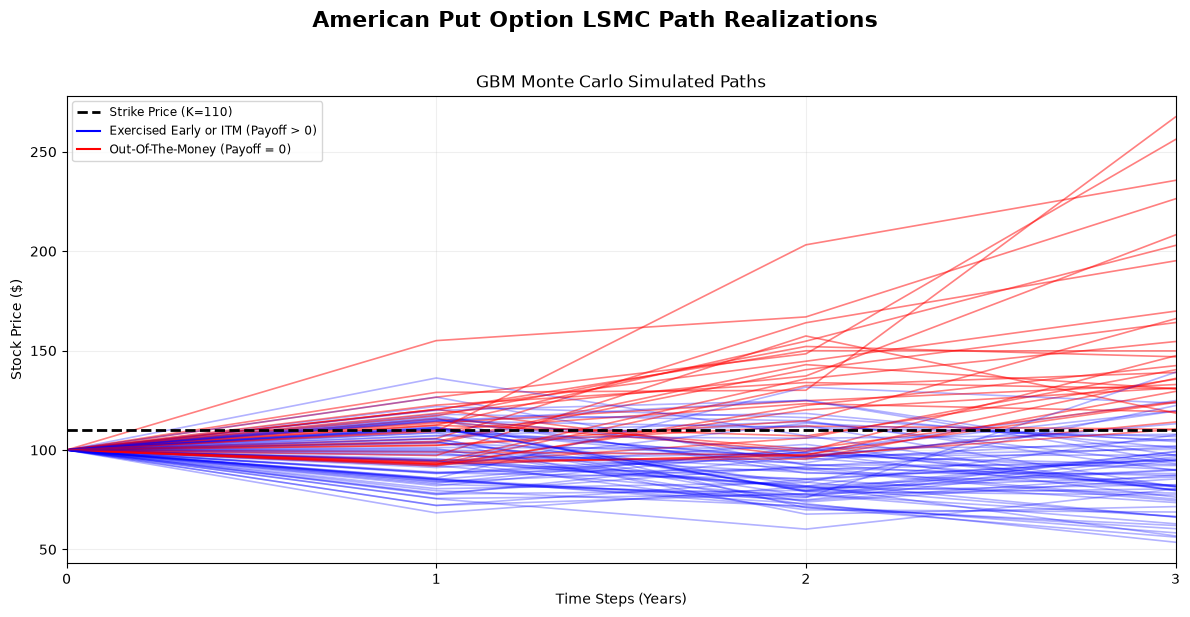

Time Step  | ITM Paths  | OTM Paths  | Exercised Paths
-------------------------------------------------------
t = 1      | 6698       | 3302       | 2805           
t = 2      | 6074       | 3926       | 1745           
t = 3      | 5680       | 4320       | 1766           


In [21]:
S0 = 100
K = 110
r = 0.03
sigma = 0.2
T = 3
M_steps = 3
N_paths = 10000

df_sim_S_paths = GBM_paths_sim(S0, r, sigma, T, M_steps, N_paths)

def get_american_put_lsmc_df(df_S_paths, K, r, T, steps, N_paths):
    dt = T / steps
    df_CF = pd.DataFrame(0.0, index=df_S_paths.index, columns=df_S_paths.columns)
    df_CF.iloc[:, steps] = np.maximum(K - df_S_paths.iloc[:, steps], 0)

    for t in range(steps - 1, 0, -1):
        S_t = df_S_paths.iloc[:, t]
        S_t_ITM = S_t < K
        if not S_t_ITM.any():
            continue
        X_itm = S_t[S_t_ITM]

        Y_future = pd.Series(0.0, index=df_S_paths.index)
        for future_t in range(t + 1, steps + 1):
            discount_factor = np.exp(-r * dt * (future_t - t))
            Y_future += df_CF.iloc[:, future_t] * discount_factor


        Y_itm = Y_future[S_t_ITM]
        X_df = pd.DataFrame({'S': X_itm, 'S_sq': X_itm**2})
        X_df = sm.add_constant(X_df)
        reg = sm.OLS(Y_itm, X_df).fit()

        print(f"--- OLS Regression Results for Year {t} ---")
        print(f"R-squared: {reg.rsquared:.4f}")
        print(reg.summary().tables[1])

        C_itm = reg.predict(X_df)
        exercise_itm = K - X_itm

        exercise_now_mask = exercise_itm > C_itm
        paths_to_exercise = X_itm[exercise_now_mask].index

        for future_t in range(t + 1, steps + 1):
            df_CF.loc[paths_to_exercise, df_S_paths.columns[future_t]] = 0.0

        df_CF.loc[paths_to_exercise, df_S_paths.columns[t]] = exercise_itm[exercise_now_mask]

    PV_paths = pd.Series(0.0, index=df_S_paths.index)
    for t in range(1, steps + 1):
        discount_factor = np.exp(-r * dt * t)
        PV_paths += df_CF.iloc[:, t] * discount_factor

    american_put_val = PV_paths.mean()
    mc_err = PV_paths.std(ddof=1) / np.sqrt(N_paths)

    return american_put_val, mc_err, df_CF

am_put_val, am_mc_err, df_CF_matrix = get_american_put_lsmc_df(df_sim_S_paths, K, r, T, M_steps, N_paths)

print(f"American Put Option Value (LSMC): {am_put_val:.4f}")
print(f"Monte Carlo Standard Error      : {am_mc_err:.4f}")


plt.rcdefaults()
num_paths_to_plot = 100
fig, ax = plt.subplots(figsize=(12, 6))

df_to_plot = df_sim_S_paths

for i in range(num_paths_to_plot):
    path = df_to_plot.iloc[i]
    if df_CF_matrix.iloc[i].sum() > 0:
        ax.plot(range(M_steps + 1), path.values, color='blue', alpha=0.3, linewidth=1.2)
    else:
        ax.plot(range(M_steps + 1), path.values, color='red', alpha=0.5, linewidth=1.2)
ax.axhline(y=K, color='black', linestyle='--', linewidth=2, label=f'Strike Price (K={K})')

ax.set_title("GBM Monte Carlo Simulated Paths", fontsize=12)
ax.set_xlabel("Time Steps (Years)", fontsize=10)
ax.set_ylabel("Stock Price ($)", fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, M_steps)
ax.set_xticks(range(M_steps + 1))

ax.plot([], [], color='blue', label='Exercised Early or ITM (Payoff > 0)')
ax.plot([], [], color='red', label='Out-Of-The-Money (Payoff = 0)')

ax.legend(loc='upper left', fontsize='small')

fig.suptitle("American Put Option LSMC Path Realizations", fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


print(f"{'Time Step':<10} | {'ITM Paths':<10} | {'OTM Paths':<10} | {'Exercised Paths':<15}")
print("-" * 55)
for t in range(1, M_steps + 1):
    S_t = df_sim_S_paths.iloc[:, t]
    CF_t = df_CF_matrix.iloc[:, t]
    itm_count = (S_t < K).sum()
    otm_count = (S_t >= K).sum()
    exercised_count = (CF_t > 0).sum()
    print(f"t = {t:<6} | {itm_count:<10} | {otm_count:<10} | {exercised_count:<15}")

### 2.5 Monte-Carlo Valuation (Time-varying Rates and volatility)

- $S_0 = 100$
- $K = 100$
- $T = 5$ years
- $R_f(t)$ is given by the term structure constructed, specifically we will use LCF calculated forward rates from (Problem 1.1)
- Volatility spot term structure: $ \quad \sigma(t) = 0.15 + 0.01t$
  where $t$ is measured in years.
- Dividends: $\$1$ paid at the end of each year
- $\Delta t = \frac{1}{12}$





,Months,t_years,Forward_Rate,Volatility,Dividend
0,1,0.083333,0.036400,0.150833,0.0
1,2,0.166667,0.036400,0.151667,0.0
2,3,0.250000,0.036400,0.152500,0.0
3,4,0.333333,0.036400,0.153333,0.0
4,5,0.416667,0.036400,0.154167,0.0
5,6,0.500000,0.036400,0.155000,0.0
6,7,0.583333,0.036400,0.155833,0.0
7,8,0.666667,0.036400,0.156667,0.0
8,9,0.750000,0.036400,0.157500,0.0
9,10,0.833333,0.036400,0.158333,0.0


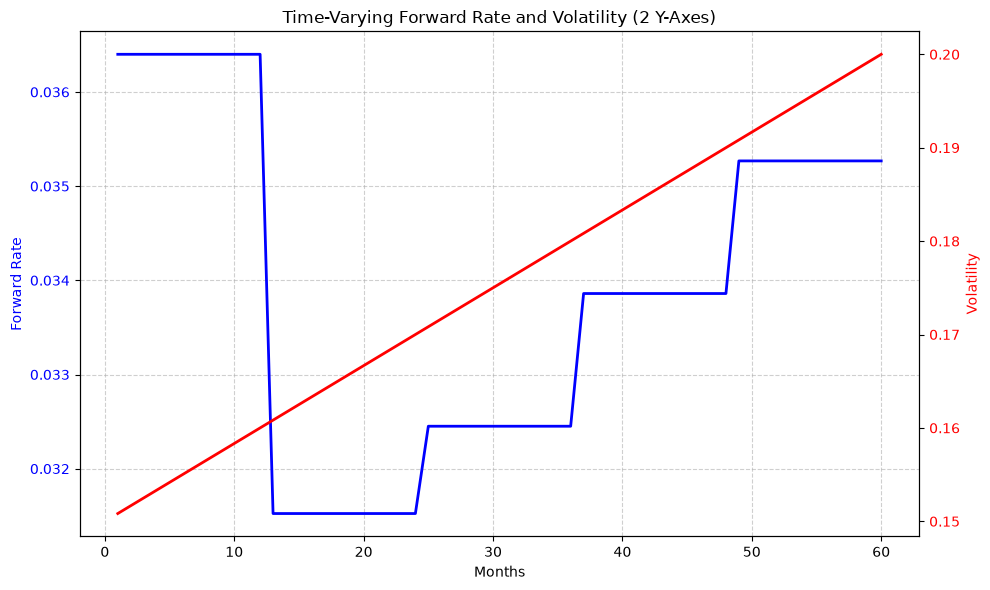

In [22]:
Fwd_LCF = [0.036400, 0.031524, 0.032451, 0.033860, 0.035268]
monthly_rates = np.repeat(Fwd_LCF, 12)
years = np.repeat([1, 2, 3, 4, 5], 12)
months = np.arange(1, 61)

df_time_var = pd.DataFrame(
    {'Months': months,
    'Forward_Rate': monthly_rates}
)
df_time_var.insert(1, 't_years', df_time_var['Months'] / 12.0)

df_time_var['Volatility'] = 0.15 + 0.01 * df_time_var['t_years']
df_time_var['Dividend'] = 0.0
df_time_var.loc[df_time_var['Months'] % 12 == 0, 'Dividend'] = 1.0

display(df_time_var.head(13))


fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(df_time_var['Months'], df_time_var['Forward_Rate'], color='blue', linewidth=2)
ax1.set_xlabel('Months')
ax1.set_ylabel('Forward Rate', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(df_time_var['Months'], df_time_var['Volatility'], color='red', linewidth=2)
ax2.set_ylabel('Volatility', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Time-Varying Forward Rate and Volatility (2 Y-Axes)')

fig.tight_layout()
plt.show()


#### European Call option on the price return
- **For each month $t=1,\dots,60$, simulate GBM:**
  $$
  S_t^{\text{pre-div}} = S_{t-1}\exp\!\left(\left(r_t-\tfrac12\sigma_t^2\right)\Delta t + \sigma_t\sqrt{\Delta t}\,Z_t\right)
  $$
    - Apply cash dividend at month-end: $ \quad
  S_t = \max\!\left(S_t^{\text{pre-div}} - D_t,\;0\right)
  $

- **Discounting Payoff with Time-Varying Rates:** $\quad
\text{DiscPayoff} = \text{DF}(0,T)\cdot \max(S_T-K,0) \quad
$ s.t.
$$
\text{DF}(0,T)=\prod_{m=1}^{60} e^{-r_m\Delta t}
= e^{-\Delta t\sum_{m=1}^{60} r_m}
$$
- **Monte Carlo Estimation:**
$$ \hat C_0
= \frac{1}{N}\sum_{i=1}^{N}
\left[
\left(\prod_{t=1}^{60} e^{-r_t \Delta t}\right)
\max\!\left(S^{(i)}_{60}-K,\;0\right)
\right].
$$

European Call Option Value: 20.5125
MC Error: 0.3254


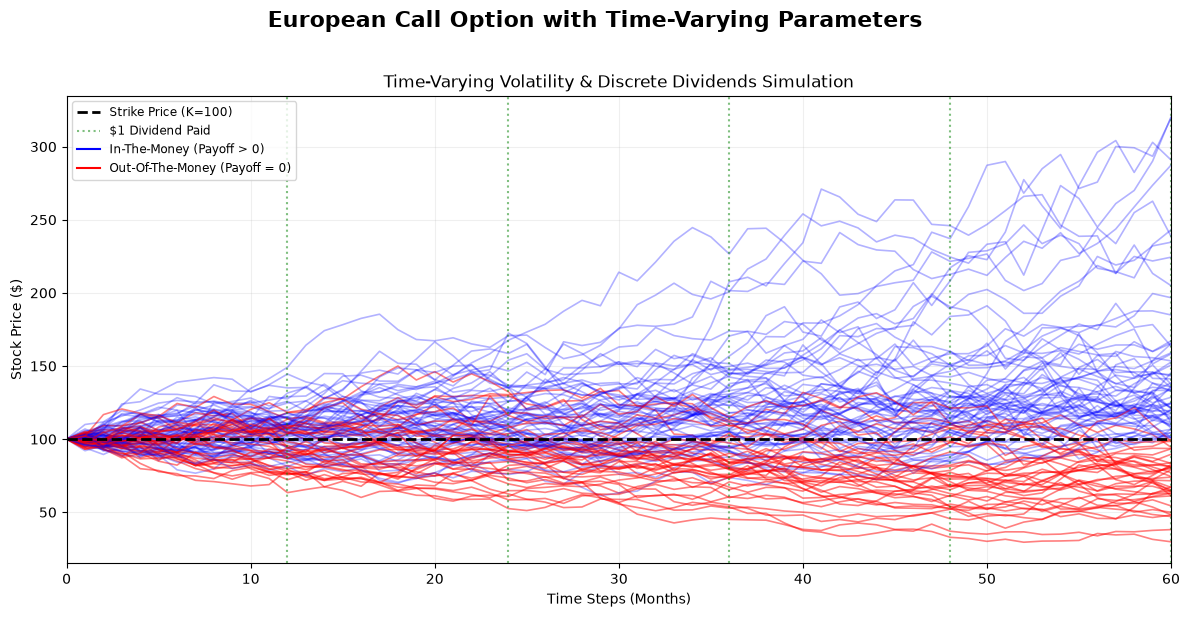

In [23]:
S0 = 100
K = 100
T = 5.0
M_steps = 60
N_paths = 10000
dt = 1/12

def GBM_paths_sim_time_varying(S0, time_var_df, steps, N_paths, dt):
    rng = np.random.default_rng(42)
    S_paths = np.zeros((N_paths, steps + 1))
    S_paths[:, 0] = S0

    for t in range(steps):
        r_t = time_var_df['Forward_Rate'].iloc[t]
        sigma_t = time_var_df['Volatility'].iloc[t]
        div_t = time_var_df['Dividend'].iloc[t]

        Zt = rng.standard_normal(size=N_paths)

        drift = (r_t - 0.5 * sigma_t ** 2) * dt
        diffusion = sigma_t * np.sqrt(dt) * Zt

        S_pre_div = S_paths[:, t] * np.exp(drift + diffusion)
        S_paths[:, t + 1] = np.maximum(S_pre_div - div_t, 0)

    col = [f"t_{i}" for i in range(steps + 1)]
    df_paths = pd.DataFrame(S_paths, columns=col)

    return df_paths


def get_call_value_time_varying(df_paths, time_var_df, K, dt):
    S_T = df_paths.iloc[:, -1]

    payoffs = np.maximum(S_T - K, 0)

    sum_of_rates = time_var_df['Forward_Rate'].sum()
    discount_fact = np.exp(-dt * sum_of_rates)
    disc_payoffs = discount_fact * payoffs

    df_val = pd.DataFrame(disc_payoffs, columns=['Discounted_Payoff'])
    option_val = disc_payoffs.mean()

    mc_err = disc_payoffs.std(ddof=1) / np.sqrt(len(disc_payoffs))

    return option_val, mc_err, df_val

df_S_time_var_paths = GBM_paths_sim_time_varying(S0, df_time_var, M_steps, N_paths,  dt)
call_val, mc_err, df_val = get_call_value_time_varying(df_S_time_var_paths, df_time_var, K, dt)

print(f"European Call Option Value: {call_val:.4f}")
print(f"MC Error: {mc_err:.4f}")

plt.rcdefaults()
num_paths_to_plot = 100
fig, ax = plt.subplots(figsize=(12, 6))

df_to_plot = df_S_time_var_paths

for i in range(num_paths_to_plot):
    path = df_to_plot.iloc[i]
    if path.iloc[-1] > K:
        ax.plot(range(M_steps + 1), path.values, color='blue', alpha=0.3, linewidth=1.2)
    else:
        ax.plot(range(M_steps + 1), path.values, color='red', alpha=0.5, linewidth=1.2)

ax.axhline(y=K, color='black', linestyle='--', linewidth=2, label=f'Strike Price (K={K})')

for m in range(12, 61, 12):
    ax.axvline(x=m, color='green', linestyle=':', alpha=0.5, label='$1 Dividend Paid' if m==12 else "")

ax.set_title("Time-Varying Volatility & Discrete Dividends Simulation", fontsize=12)
ax.set_xlabel("Time Steps (Months)", fontsize=10)
ax.set_ylabel("Stock Price ($)", fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, M_steps)

ax.plot([], [], color='blue', label='In-The-Money (Payoff > 0)')
ax.plot([], [], color='red', label='Out-Of-The-Money (Payoff = 0)')

ax.legend(loc='upper left', fontsize='small')

fig.suptitle("European Call Option with Time-Varying Parameters", fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

####  European Call option assuming the dividends are reinvested (Total return)

- **For each month $t=1,\dots,60$, simulate the same ex-dividend GBM price path:**
  $$
  S_t^{\text{pre-div}} = S_{t-1}\exp\!\left(\left(r_t-\tfrac12\sigma_t^2\right)\Delta t + \sigma_t\sqrt{\Delta t}\,Z_t\right)
  $$
  - Apply cash dividend at month-end:
  $
  S_t = \max\!\left(S_t^{\text{pre-div}} - D_t,\;0\right)
  $

- **Reinvestment of dividends:** track shares held, starting with one share.
  - Let $n_0=1$ and portfolio value $W_t=n_t S_t$.
  - At dividend months, dividend cash is reinvested into additional shares:
  $$
  n_t = n_{t-1} + \frac{n_{t-1}D_t}{S_t}
  \qquad (\text{when } D_t>0)
  $$
  - If $D_t=0$, then $n_t=n_{t-1}$.

- **Total-return adjusted terminal payoff:**$ \quad W_T=n_T S_T$
  $$
  \text{Payoff} = \max(W_T-K,0), \qquad
  $$

- **Discounting Payoff with Time-Varying Rates:** $\quad
\text{DiscPayoff} = \text{DF}(0,T)\cdot \max(W_T-K,0) \quad
$

- **Monte Carlo Estimation:**
$$
\hat C_0
= \frac{1}{N}\sum_{i=1}^{N}
\left[
\left(\prod_{t=1}^{60} e^{-r_t \Delta t}\right)
\max\!\left(W^{(i)}_{60}-K,\;0\right)
\right],
\qquad W^{(i)}_{60}=n^{(i)}_{60}S^{(i)}_{60}.
$$

In [24]:
def GBM_paths_sim_reinvested(S0, time_var_df, steps, N_paths, dt):
    rng = np.random.default_rng(42)

    S_paths = np.zeros((N_paths, steps + 1))
    S_paths[:, 0] = S0

    n_paths = np.ones((N_paths, steps + 1))

    for t in range(steps):
        r_t = time_var_df['Forward_Rate'].iloc[t]
        sigma_t = time_var_df['Volatility'].iloc[t]
        div_t = time_var_df['Dividend'].iloc[t]

        Zt = rng.standard_normal(size=N_paths)

        drift = (r_t - 0.5 * sigma_t ** 2) * dt
        diffusion = sigma_t * np.sqrt(dt) * Zt

        S_pre_div = S_paths[:, t] * np.exp(drift + diffusion)
        S_paths[:, t + 1] = np.maximum(S_pre_div - div_t, 0)
        if div_t > 0:
            n_paths[:, t + 1] = n_paths[:, t] + (n_paths[:, t] * div_t) / np.maximum(S_paths[:, t + 1], 1e-8)
        else:
            n_paths[:, t + 1] = n_paths[:, t]

    W_paths = n_paths * S_paths

    col = [f"t_{i}" for i in range(steps + 1)]
    df_W_paths = pd.DataFrame(W_paths, columns=col)

    return df_W_paths

df_W_reinvested_paths = GBM_paths_sim_reinvested(S0, df_time_var, M_steps, N_paths, dt)

call_val_reinvest, mc_err_reinvest, df_val_reinvest = get_call_value_time_varying(df_W_reinvested_paths, df_time_var, K, dt)

print(f"Total Return Call Value : ${call_val_reinvest:.4f}")
print(f"Monte Carlo Error       : ${mc_err_reinvest:.4f}")

Total Return Call Value : $23.3620
Monte Carlo Error       : $0.3440
